# Student Performance Prediction Using Machine Learning

# Introduction

Student Performance Prediction is a Machine Learning project that aims to predict students' final academic scores based on various factors such as study hours, attendance percentage, sleep duration, previous academic performance, extracurricular participation, and parental education level. Educational institutions can use such predictive models to identify students who may need additional support and to improve overall academic outcomes.

In this project, a dataset containing student-related information is analyzed using data science and machine learning techniques. The data undergoes preprocessing, exploratory data analysis (EDA), and feature engineering to uncover meaningful patterns and relationships. Multiple machine learning models, including Linear Regression, Random Forest Regressor, and XGBoost Regressor, are trained and evaluated to determine the most accurate approach for predicting student performance.

The project follows a complete machine learning workflow consisting of problem understanding, data preprocessing, exploratory data analysis, feature engineering, model training, evaluation, and prediction. The performance of the models is assessed using evaluation metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. The ultimate goal is to build a reliable predictive system that can assist educators and institutions in making data-driven decisions to enhance student success.


# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Uploading Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Student_Performance_Dataset.csv to Student_Performance_Dataset.csv


# Load Dataset

In [3]:
df = pd.read_csv("Student_Performance_Dataset.csv")

df.head()

,student_id,gender,school_type,study_hours_daily,attendance_pct,sleep_hours,previous_score,extracurricular,parent_education,final_marks
0,1,Female,Private,5.3,67.3,8.8,48,0,Grad,55
1,2,Female,Public,7.5,63.0,6.7,69,0,Grad,69
2,3,Male,Private,8.2,83.3,5.1,59,0,NaN,70
3,4,Male,Public,7.8,88.6,6.3,57,1,NaN,71
4,5,Male,Private,4.3,57.1,4.8,37,1,PG,36


# Problem Understanding

Dataset Shape

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (500, 10)


Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         500 non-null    int64  
 1   gender             500 non-null    object 
 2   school_type        500 non-null    object 
 3   study_hours_daily  500 non-null    float64
 4   attendance_pct     500 non-null    float64
 5   sleep_hours        500 non-null    float64
 6   previous_score     500 non-null    int64  
 7   extracurricular    500 non-null    int64  
 8   parent_education   345 non-null    object 
 9   final_marks        500 non-null    int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 39.2+ KB


Statistical Summary

In [6]:
df.describe()

,student_id,study_hours_daily,attendance_pct,sleep_hours,previous_score,extracurricular,final_marks
count,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,5.701200,73.52480,6.890000,56.756000,0.512000,60.172000
std,144.481833,1.958824,14.35995,1.224344,14.656401,0.500357,16.783736
min,1.000000,0.500000,40.00000,3.500000,20.000000,0.000000,10.000000
25%,125.750000,4.500000,63.47500,6.100000,47.000000,0.000000,50.000000
50%,250.500000,5.700000,72.70000,6.900000,57.000000,1.000000,60.000000
75%,375.250000,6.925000,84.20000,7.700000,67.000000,1.000000,71.000000
max,500.000000,11.200000,100.00000,10.000000,95.000000,1.000000,98.000000


# Missing Values Check

In [7]:
df.isnull().sum()

,0
student_id,0
gender,0
school_type,0
study_hours_daily,0
attendance_pct,0
sleep_hours,0
previous_score,0
extracurricular,0
parent_education,155
final_marks,0


# Handle Missing Values

In [8]:
df['study_hours_daily'].fillna(
    df['study_hours_daily'].median(),
    inplace=True
)

df['attendance_pct'].fillna(
    df['attendance_pct'].mean(),
    inplace=True
)

df['parent_education'].fillna(
    df['parent_education'].mode()[0],
    inplace=True
)

# Duplicate Records

In [9]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


# Exploratory Data Analysis (EDA)

Graph 1: Study Hours vs Final Marks

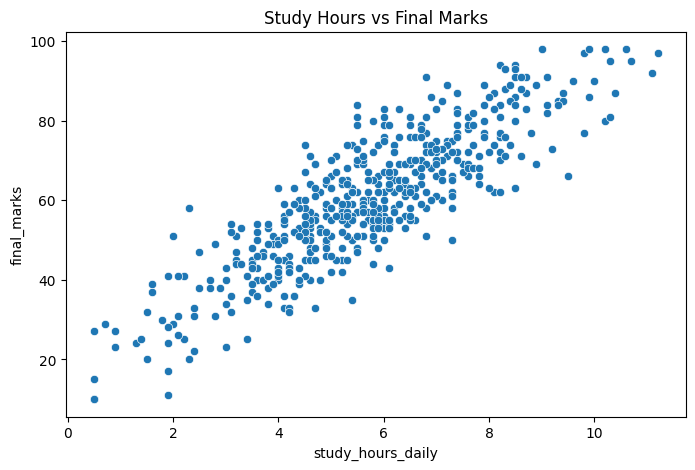

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='study_hours_daily',
    y='final_marks',
    data=df
)

plt.title("Study Hours vs Final Marks")
plt.show()

Graph 2: Final Marks Distribution

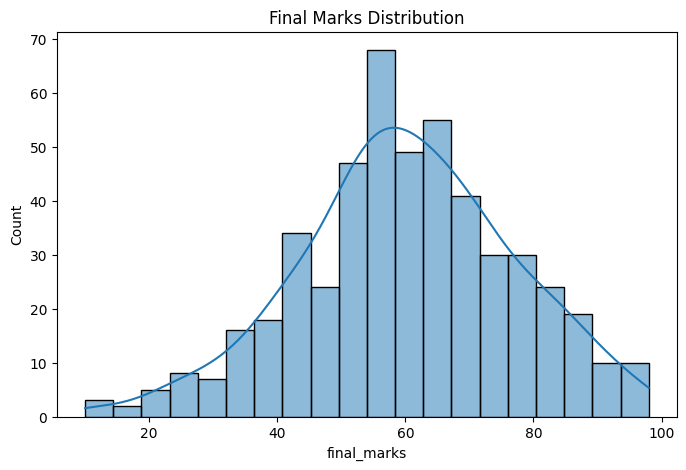

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['final_marks'],
    bins=20,
    kde=True
)

plt.title("Final Marks Distribution")
plt.show()

Graph 3: Attendance vs Final Marks

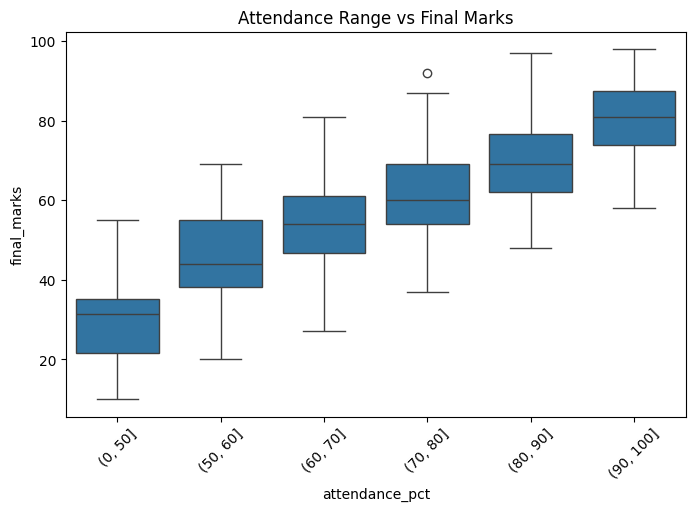

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=pd.cut(
        df['attendance_pct'],
        bins=[0,50,60,70,80,90,100]
    ),
    y='final_marks',
    data=df
)

plt.xticks(rotation=45)
plt.title("Attendance Range vs Final Marks")
plt.show()

Graph 4: Correlation Heatmap

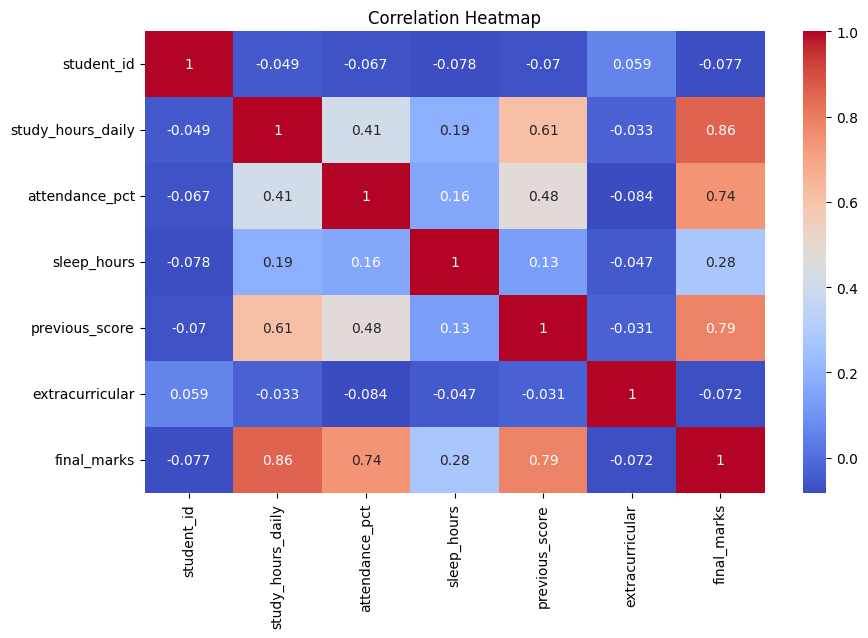

In [13]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessing

Label Encoding

In [14]:
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])

df['school_type'] = le.fit_transform(
    df['school_type']
)

Parent Education Encoding

In [15]:
parent_map = {
    'None':0,
    'Grad':1,
    'PG':2
}

df['parent_education'] = (
    df['parent_education']
    .map(parent_map)
)

Feature Scaling

In [16]:
scaler = MinMaxScaler()

num_cols = [
    'study_hours_daily',
    'attendance_pct',
    'sleep_hours'
]

df[num_cols] = scaler.fit_transform(
    df[num_cols]
)

# Feature Engineering

In [17]:
df['study_effectiveness'] = (
    df['study_hours_daily']
    *
    df['attendance_pct']
)

df['sleep_study_ratio'] = (
    df['sleep_hours']
    /
    df['study_hours_daily']
    .replace(0,0.1)
)

df['engagement_score'] = (
    df['study_hours_daily']*0.5
    +
    df['attendance_pct']*0.3
    +
    df['extracurricular']*0.2
)

Drop Student ID

In [18]:
df.drop(
    columns=['student_id'],
    inplace=True
)

# Train Test Split

In [19]:
X = df.drop(
    'final_marks',
    axis=1
)

y = df['final_marks']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression

In [20]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

y_pred_lr = lr_model.predict(X_test)

# Random Forest

In [21]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(X_test)

# XGBoost

In [22]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb_model.predict(X_test)

# Model Evaluation

In [23]:
def evaluate(name, y_true, y_pred):

    mae = mean_absolute_error(y_true,y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true,y_pred)
    )

    r2 = r2_score(y_true,y_pred)

    return [name, mae, rmse, r2]
results = pd.DataFrame([

evaluate(
    "Linear Regression",
    y_test,
    y_pred_lr
),

evaluate(
    "Random Forest",
    y_test,
    y_pred_rf
),

evaluate(
    "XGBoost",
    y_test,
    y_pred_xgb
)

],

columns=[
    "Model",
    "MAE",
    "RMSE",
    "R2 Score"
])

results




,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.227952,2.834222,0.972323
1,Random Forest,3.154370,3.915606,0.947174
2,XGBoost,3.067567,3.808376,0.950028


# R² Comparison Graph

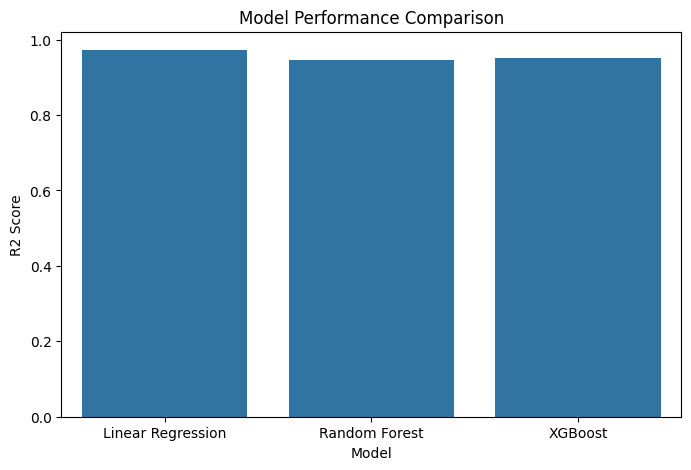

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title("Model Performance Comparison")
plt.show()

# Feature Importance

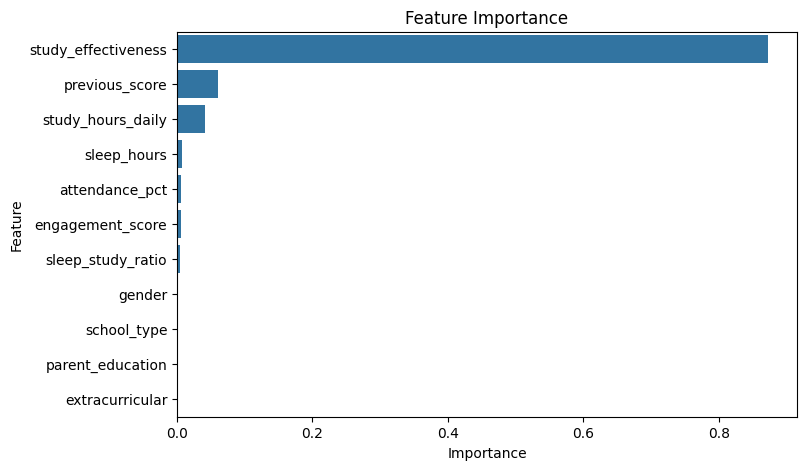

In [27]:
importance = pd.DataFrame({

'Feature':X.columns,

'Importance':
rf_model.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()


# Sample Prediction

In [28]:
sample = X_test.iloc[[0]]

prediction = xgb_model.predict(sample)

print("Predicted Marks:",
      round(prediction[0],2))

print("Actual Marks:",
      y_test.iloc[0])

Predicted Marks: 93.2
Actual Marks: 91


# Save Model

In [29]:
import joblib

joblib.dump(
    xgb_model,
    "xgboost_student_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

• Built a complete end-to-end machine learning pipeline.
• Performed EDA and preprocessing.
• Created engineered features.
• Trained Linear Regression, Random Forest and XGBoost.
• Compared models using MAE, RMSE and R² Score.
• XGBoost achieved the best prediction performance.
• Study Hours, Attendance and Previous Score were the strongest predictors of student performance.